# XRL-Contrastive: Explaining Multi-Objective RL Agents

**Goal.** Train three multi-objective DQN agents that differ in priority along a
**navigation-vs-collection** axis, then explain *how* and *why* they behave
differently using per-channel reward decomposition, contrastive explanations,
and TCAV concept attribution.

**What this notebook is.** A *report*: it loads the trained checkpoints in
`checkpoints/` (no retraining) and renders the analysis. Plotting helpers live
in `report_utils.py` to keep the notebook lean.

**Why goal-vs-coin (not safety-vs-speed).** We first tried "safety-first vs
speed-first" agents, but in this grid the shortest path is *also* the safest, so
there is no safety/speed trade-off — all agents converged to equivalent 18-step
routes and the explanations could not distinguish them. Goal-vs-coin *does*
create a genuine trade-off (detour for resources vs go straight), so the agents
are actually distinguishable. Safety is kept as a **shared** concern (every agent
avoids hazards).

**Headline results.**
- All three agents reach the goal with **100% success** — achieved only after
  diagnosing and fixing an overestimation-driven training collapse.
- They are **genuinely distinct in collection**: navigator grabs 1 coin on a
  direct 18-step path; balanced grabs 2; collector **detours to grab 3** on a
  20-step path.
- **Reward decomposition recovers this cleanly** (coin contribution: navigator
  ≈0, collector large) — because it includes the weights.
- **TCAV finding:** methods that include the weights (decomposition, total-Q
  TCAV) recover the personality; a weight-agnostic *per-channel* TCAV does **not**
  — the personality lives in the *weights*, not in the per-channel Q-values
  (which are shared because the reward signals are identical).


In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import report_utils as ru
from agents.configs import PROFILES, REWARD_CHANNELS
from envs.multi_obj_grid import MultiObjGridEnv

agents = ru.load_agents()
print("Loaded agents:", ", ".join(agents))

Loaded agents: navigator, collector, balanced


## 1. Problem setup

A 10×10 grid (start `(0,0)`, goal `(9,9)`) with 10 hazard cells (terminal,
reward −10) and 8 resource/coin cells (reward +0.5). Every step costs −0.15. The
environment exposes a **4-channel reward vector** `[goal, safety, coin, step]`.

Each agent is a **DecomposedDQN**: a shared encoder feeding four per-channel
Q-heads; the greedy action maximises the weighted sum `Σ wᵢ·Qᵢ`. The weights
define the personality along the goal-vs-coin axis (reward *signs* live in the
reward vector, so weights are positive magnitudes; `w_safety` is shared so all
agents avoid hazards):


,agent,"weights [goal,safety,coin,step]",n_step,style
0,Agent α (navigator),"[3.0, 1.0, 0.0, 1.0]",3,Heads straight for the goal; ignores resources
1,Agent β (collector),"[1.2, 1.0, 5.0, 0.2]",3,Detours to collect resources on its way to the...
2,Agent γ (balanced),"[1.5, 1.0, 1.5, 0.4]",3,Collects some resources while still reaching t...


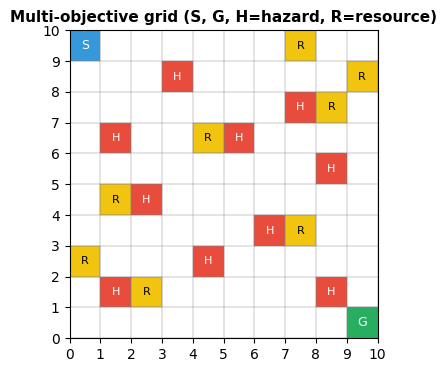

In [2]:
rows = [{"agent": p["name"], "weights [goal,safety,coin,step]": p["weights"],
         "n_step": p["n_step"], "style": p["description"]}
        for p in PROFILES.values()]
display(pd.DataFrame(rows))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4, 4))
ru.draw_grid(MultiObjGridEnv(), title="Multi-objective grid (S, G, H=hazard, R=resource)", ax=ax)
plt.show()

## 2. Training stability — the core engineering problem

Naive training left **all three agents at 0% success**. This was not a
hyperparameter mishap: it is the **overestimation bias / deadly triad** of
value-based deep RL (max operator + bootstrapping + function approximation),
exactly the phenomenon studied in the supervisor's line of work on multi-step
and ensemble DQN. Diagnostic instrumentation showed Q-values diverging (e.g.
`Q_safety` inflating to +600 when it can only ever be ≤ 0) and the greedy policy
collapsing into wall-bumping / self-loops once exploration decayed.

**Antidotes tried, and why the textbook ones failed here:**

| Fix | Outcome | Reason |
|-----|---------|--------|
| Target network (already present) | necessary, insufficient | basic stability only |
| Huber loss | **hurt** | sparse-reward env: the rare ±10 signal *is* the signal; Huber clips exactly it |
| Double DQN | **hurt** | its removal of optimistic bias suppresses the exploration that finds the goal |
| **n-step return** | **fixed it** | accumulates real reward before bootstrapping → dilutes the deadly triad |

**The bootstrap horizon `n` still matters per-agent.** The goal-heavy navigator
(`w_goal=3`) *diverged* in Q-magnitude at `n=1` (its decomposition ran from +179
to −1137 along a single path while the policy stayed correct) and needed `n=3`
to stay bounded — a larger `n` dilutes the single-step feedback that drives
divergence. This coupling between `n` and the reward structure is precisely what
motivates **Elastic Step DQN** (adaptive `n`).

A **best-model checkpoint** guards against late-training divergence. Its
selection signal is the window-average *scalarised return* (`Σ wᵢ·channelᵢ`),
i.e. the quantity each agent actually optimises — so the collector (which barely
values the goal) is scored on the coins it gathers, not a goal-rate. Dashed lines
below mark the saved snapshots.


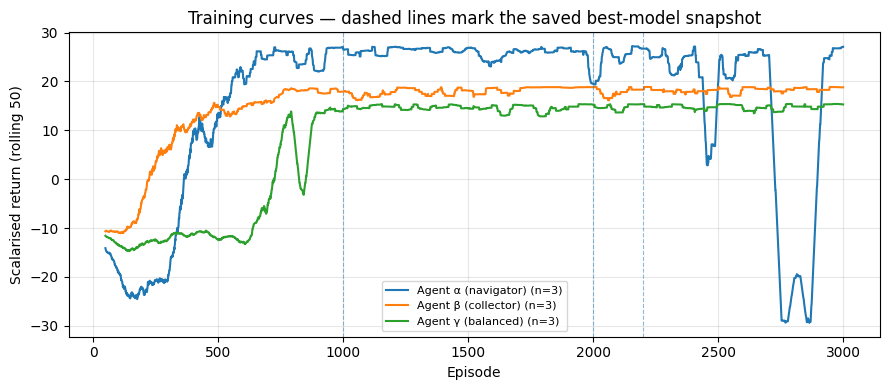

In [3]:
fig = ru.plot_training_curves(agents); import matplotlib.pyplot as plt; plt.show()

## 3. Results — all three solve the task, but differently

Every agent reaches the goal deterministically (ε=0) with zero hazard violations.
The personalities show in **collection and path length**: the collector detours
(20 steps) to grab 3 coins; the navigator goes straight (18 steps, 1 incidental
coin); the balanced agent is in between.


,agent,n_step,success,R1,R2,length,safety_violations
0,Agent α (navigator),3,1.0,7.3,0.5,18.0,0
1,Agent β (collector),3,1.0,7.0,1.5,20.0,0
2,Agent γ (balanced),3,1.0,7.3,1.0,18.0,0


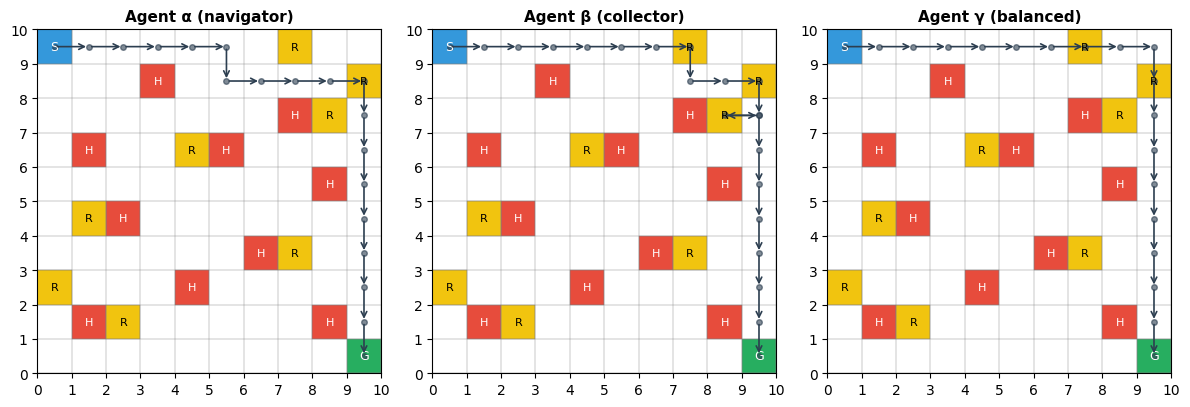

In [4]:
display(pd.DataFrame(ru.metrics_table(agents, n_eval=100)))
fig = ru.plot_trajectories(agents); import matplotlib.pyplot as plt; plt.show()

## 4. Explainability

### 4.1 Reward decomposition — recovers the personality

Because the DQN has per-channel heads, every decision decomposes intrinsically
into `wᵢ·Qᵢ` contributions. Averaged along each agent's own path, the **coin
channel cleanly separates the agents** — exactly as their weights dictate:


,agent,mean coin contribution,mean goal contribution
0,Agent α (navigator),0.00,26.25
1,Agent β (collector),3.36,10.50
2,Agent γ (balanced),0.68,13.66


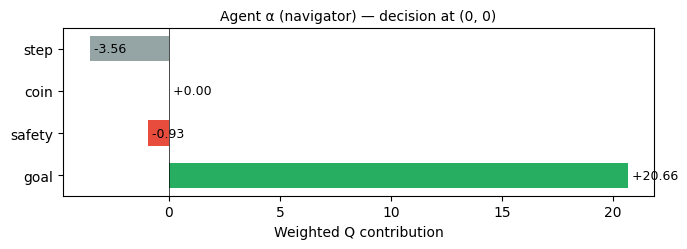

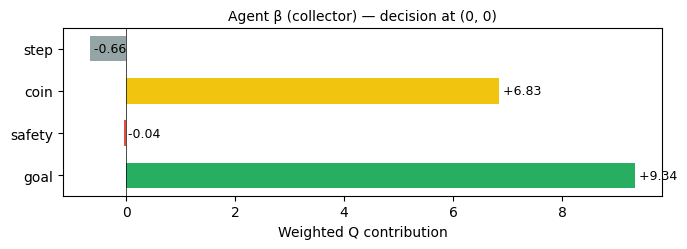

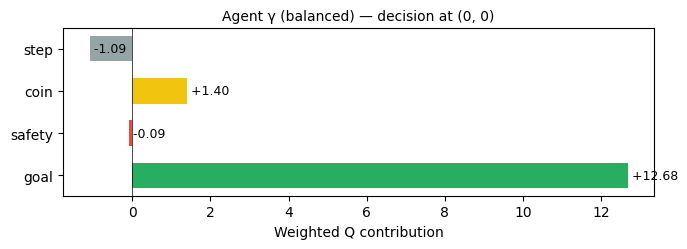

In [5]:
from xai.reward_decomp import trajectory_decomposition
import matplotlib.pyplot as plt
rows = []
for key, ag in agents.items():
    steps = trajectory_decomposition(ag["model"], ag["weights"])
    rows.append({"agent": ag["name"],
                 "mean coin contribution": round(np.mean([s["greedy_channel_contributions"]["coin"] for s in steps]), 2),
                 "mean goal contribution": round(np.mean([s["greedy_channel_contributions"]["goal"] for s in steps]), 2)})
display(pd.DataFrame(rows))
for key, ag in agents.items():
    d = trajectory_decomposition(ag["model"], ag["weights"])[0]
    ru.plot_reward_decomposition(d, title=f"{ag['name']} — decision at {d['position']}")
    plt.show()

The navigator's coin contribution is ≈0 (it weights coins at 0), while the
collector's is large — the decomposition *recovers the designed personality*
because it includes the weights. (This works precisely because the agents are now
genuinely behaviourally distinct, unlike the earlier safety/speed agents.)


### 4.2 Contrastive explanations

We compare agents at states **on their actual greedy trajectories** (the union of
both paths) — reachable, in-distribution states, not random possibly-unreachable
cells. At a state on agent A's path, agent B's action is a counterfactual.

The navigator-vs-collector contrast now reflects a real objective difference: the
collector detours toward resources where the navigator heads straight on.


In [6]:
from xai.contrastive import find_trajectory_disagreements, generate_explanation
import itertools
for ka, kb in itertools.combinations(list(agents), 2):
    a, b = agents[ka], agents[kb]
    dis = find_trajectory_disagreements(a["model"], a["weights"], b["model"], b["weights"])
    print(f"=== {a['name']} vs {b['name']}: {len(dis)} on-path disagreements ===")
    for d in dis[:2]:
        print(generate_explanation(d, a["name"], b["name"])); print()
    print()

=== Agent α (navigator) vs Agent β (collector): 15 on-path disagreements ===
At position (0,5):
  Agent α (navigator) chose DOWN [→ (1,5): open] (Q_total = +21.23) — the step channel tips this choice: moving down minimises step cost.
  Agent β (collector) chose RIGHT [→ (0,6): open] (Q_total = +16.35) — the coin channel tips this choice: moving right leads to a nearby resource.
  → Agent α (navigator) is driven by step, while Agent β (collector) is driven by coin.

At position (1,5):
  Agent α (navigator) chose RIGHT [→ (1,6): open] (Q_total = +22.67) — the goal channel tips this choice: heading right brings it closer to the goal.
  Agent β (collector) chose UP [→ (0,5): open] (Q_total = +15.90) — the goal channel tips this choice: heading up brings it closer to the goal.
  → Both are tipped by the goal channel here but take different routes — Agent α (navigator) goes right, Agent β (collector) goes up.


=== Agent α (navigator) vs Agent γ (balanced): 9 on-path disagreements ===
At pos

*For interactive per-state exploration of all three agents at once, run the
dashboard:* `streamlit run dashboard/app.py` (Explore tab).


### 4.3 TCAV — which methods recover the personality?

**Total-Q TCAV** (standard TCAV on the weighted total Q) partly tracks the
personality: the navigator, weighting coins at 0, is the *least* sensitive to the
`near_resource` concept.


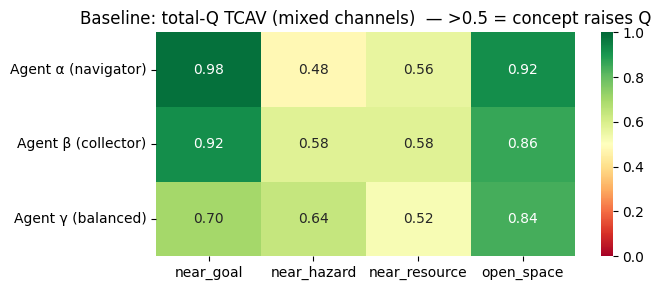

In [7]:
from xai.tcav import run_tcav_analysis
import matplotlib.pyplot as plt
total_tcav = {k: run_tcav_analysis(a["model"], a["weights"], n_samples=120) for k, a in agents.items()}
fig = ru.plot_total_tcav(total_tcav, agents); plt.show()

**Per-channel TCAV** probes each channel head's gradient *without the
weights*. It does **not** separate the agents on `coin×near_resource`:


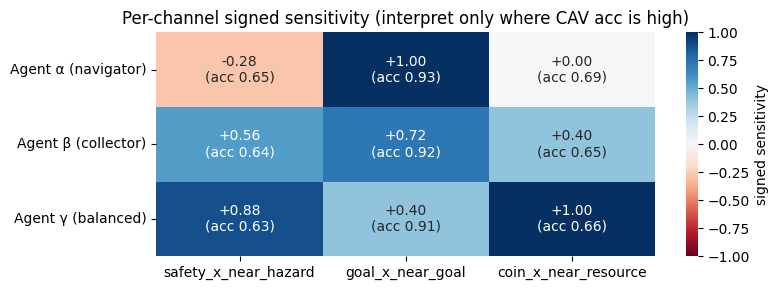

In [8]:
from xai.tcav import run_per_channel_tcav
import matplotlib.pyplot as plt
per_channel = {k: run_per_channel_tcav(a["model"]) for k, a in agents.items()}
fig = ru.plot_per_channel_tcav(per_channel, agents); plt.show()

**Why the difference — the key methodological finding.** The three agents
see *identical* reward signals, so their per-channel Q-*values* are shared in
principle (a coin is worth the same to every coin-head). What differs is the
**weight** each agent puts on the coin channel. Therefore:

- **Weight-aware methods recover the personality:** reward decomposition (`wᵢ·Qᵢ`)
  and total-Q TCAV (gradient of the weighted Q) both see the weights.
- **A weight-agnostic per-channel TCAV does not:** it probes `∂Q_channel/∂features`,
  i.e. the *shared* head, so it is blind to the weights that define the personality.

Signs are only trustworthy where the CAV separates the concept (`near_goal`
≈0.95 reliable; `near_hazard` ≈0.6, near chance — not interpreted; accuracies are
annotated per cell).


## 5. Limitations & connection to the research direction

- **Personality lives in the weights.** The decisive XAI result: an explanation
  must incorporate the scalarisation weights to recover a multi-objective agent's
  character; probing the shared per-channel Q-values alone cannot.
- **The environment shapes which personalities are expressible.** Safety-vs-speed
  produced no behavioural trade-off (shortest = safest); goal-vs-coin did. XAI can
  only explain differences the agents actually exhibit.
- **Per-channel TCAV reliability is concept-dependent** (`near_hazard` barely
  separable); conclusions are drawn only where CAV accuracy is high.
- **The training-stability arc is the main engineering contribution.**
  Independently rediscovering overestimation-driven collapse, ruling out
  Huber/Double-DQN for sparse rewards, and finding the bootstrap horizon `n` must
  grow with a channel's weight to stay bounded, connects directly to **Elastic /
  Ensemble Step DQN** (adaptive bootstrap horizon).

*Reproduce training (optional):* `python -m experiments.run_all --phase train`.
This report only consumes the committed checkpoints.
